2D Navier–Stokes (vorticity form) — quick IC evolution & diagnostics

This notebook does:

1. Generate a random initial field `w(x,y)` that is divergence free
2. Generate a good IC from that 

In [1]:
# ----------------------------
# Imports & configuration
# ----------------------------
from __future__ import annotations

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import jax_cfd.base as cfd
import jax_cfd.base.grids as grids
import jax_cfd.spectral as spectral

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# Create divergence free, non-physical IC
# ----------------------------
def random_div_free_omega_jax(N: int,k0: float,bandwidth: float = 1.0,seed: int = 0,L: float = 2.0 * jnp.pi,omega_rms: float = 1.0,dtype=jnp.float64,):
    """
    JAX random divergence-free IC generator.

    Returns:
      omega : (N,N) real
      u, v  : (N,N) real (divergence-free)
      psi   : (N,N) real
      kx    : (N,)        FFT wavenumbers (rad/unit)
      ky    : (N//2+1,)   rFFT wavenumbers (rad/unit) for the last axis
    """
    key = jax.random.PRNGKey(seed)

    # Grid spacing in physical space
    dx = L / N

    # Wavenumbers (rad/unit length) consistent with JAX FFT conventions
    kx = 2.0 * jnp.pi * jnp.fft.fftfreq(N, d=dx)       # (N,)
    ky = 2.0 * jnp.pi * jnp.fft.rfftfreq(N, d=dx)      # (N//2+1,)

    KX = kx[:, None]                                   # (N,1)
    KY = ky[None, :]                                   # (1,N//2+1)
    K2 = KX**2 + KY**2
    K = jnp.sqrt(K2)

    # Band-pass ring mask, exclude k=0
    mask = (K >= (k0 - bandwidth)) & (K <= (k0 + bandwidth)) & (K2 > 0)

    # Sample complex ψ̂ on rFFT half-plane
    key_re, key_im = jax.random.split(key, 2)
    re = jax.random.normal(key_re, shape=(N, N//2 + 1), dtype=jnp.float64)
    im = jax.random.normal(key_im, shape=(N, N//2 + 1), dtype=jnp.float64)

    psi_hat = (re + 1j * im) * mask

    # Enforce reality constraints for irfft:
    # ky=0 and (if N even) ky=N/2 columns must be purely real
    psi_hat = psi_hat.at[:, 0].set(jnp.real(psi_hat[:, 0]) + 0j)
    if N % 2 == 0:
        psi_hat = psi_hat.at[:, -1].set(jnp.real(psi_hat[:, -1]) + 0j)

    # Also remove mean mode
    psi_hat = psi_hat.at[0, 0].set(0.0 + 0.0j)

    # Transform to real space
    psi = jnp.fft.irfftn(psi_hat, s=(N, N))

    # Spectral derivatives (stay in rFFT space)
    u_hat = (1j * KY) * psi_hat          # u = dψ/dy
    v_hat = (-1j * KX) * psi_hat         # v = -dψ/dx
    omega_hat = -K2 * psi_hat            # ω = ∇²ψ

    u = jnp.fft.irfftn(u_hat, s=(N, N))
    v = jnp.fft.irfftn(v_hat, s=(N, N))
    omega = jnp.fft.irfftn(omega_hat, s=(N, N))

    # Normalize by omega RMS
    rms = jnp.sqrt(jnp.mean(omega**2))
    scale = jnp.where(rms > 0, omega_rms / rms, 1.0)

    psi = (psi * scale).astype(dtype)
    u = (u * scale).astype(dtype)
    v = (v * scale).astype(dtype)
    omega = (omega * scale).astype(dtype)

    return omega, u, v, psi, kx.astype(jnp.float64), ky.astype(jnp.float64)

In [3]:
# ----------------------------
# User Knobs
# ----------------------------
OUT = Path(".../IC.nc")

N = size = 512
k0 = 4.0
bandwidth = 1.0
seed = 0
omega_rms = 1

density = 1.
viscosity = 1e-5
cfl_safety_factor = 0.3

drag=0.05
forcing_amplitude = 0.125
forcing_frequency = k0

omega, u, v, psi, kx, ky = random_div_free_omega_jax(N, k0, bandwidth=bandwidth, seed=seed, omega_rms=1.0)

print("omega shape:", omega.shape)
print("omega RMS:", float(jnp.sqrt(jnp.mean(omega**2))))

omega shape: (512, 512)
omega RMS: 1.0000000000000002


In [4]:
# ----------------------------
# Check divergence-free condition
# ----------------------------
u_hat = jnp.fft.rfftn(u)
v_hat = jnp.fft.rfftn(v)

L = 2.0 * jnp.pi
dx = L / N
kx_full = 2.0 * jnp.pi * jnp.fft.fftfreq(N, d=dx)      # (N,)
ky_half = 2.0 * jnp.pi * jnp.fft.rfftfreq(N, d=dx)     # (N//2+1,)

KX = kx_full[:, None]
KY = ky_half[None, :]

div_hat = (1j * KX) * u_hat + (1j * KY) * v_hat
div = jnp.fft.irfftn(div_hat, s=(N, N))

print("max |div|:", float(jnp.max(jnp.abs(div))))
print("mean |div|:", float(jnp.mean(jnp.abs(div))))

max |div|: 6.200964222782238e-14
mean |div|: 8.938944444530824e-15


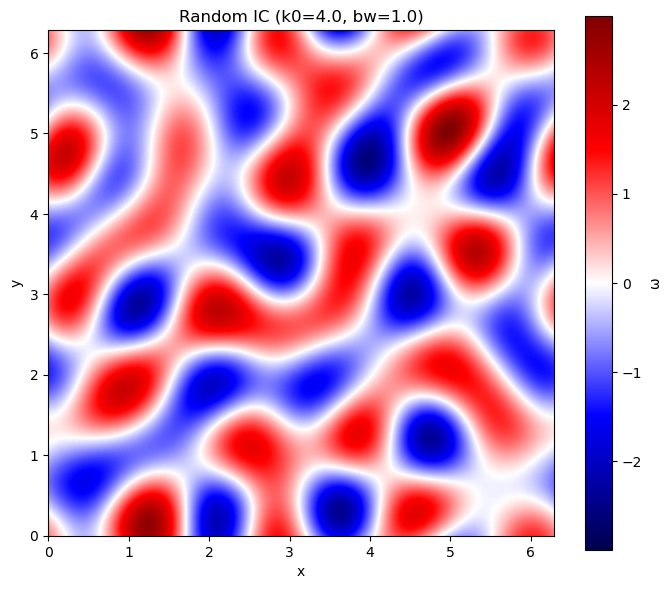

In [5]:
# ----------------------------
# Plot it
# ----------------------------
omega_np = jnp.asarray(omega)
vmax = float(jnp.max(jnp.abs(omega_np)))

plt.figure(figsize=(7,6))
plt.imshow(
    omega_np,
    cmap="seismic",
    origin="lower",
    extent=[0, 2*jnp.pi, 0, 2*jnp.pi],
    vmin=-vmax,
    vmax=vmax,
)
plt.colorbar(label="ω")
plt.title(f"Random IC (k0={k0}, bw={bandwidth})")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()
plt.show()

In [6]:
# ----------------------------
# Some inputs
# ----------------------------
Lx =  2*jnp.pi
Ly = Lx 
dy = Lx/size
dx = Ly/size
grid = grids.Grid((size, size), domain=((0, 2 * jnp.pi), (0, 2 * jnp.pi)))
max_velocity = jnp.max(jnp.sqrt(u**2+v**2))
dt = cfd.equations.stable_time_step(max_velocity, cfl_safety_factor, viscosity, grid)
print("Minimum dt:", dt)

Minimum dt: 0.006904711426981343


In [7]:
# ----------------------------
# Choose your timesteps
# ----------------------------
dt = 0.005
inner_steps = 10/dt      
outer_steps = 50    
print("dt_used:", dt)

dt_used: 0.005


In [8]:
# ----------------------------
# Integrate Navier-Stokes
# ----------------------------
smooth = True 
forcing_fn = lambda g: spectral.forcings.checkerboard_forcing_module(g, freq=forcing_frequency, amp=forcing_amplitude)

model = spectral.equations.NavierStokes2D(viscosity, grid,drag=drag,smooth=smooth,forcing_fn=forcing_fn)

step_fn = spectral.time_stepping.crank_nicolson_rk4(model, dt)

trajectory_fn = cfd.funcutils.trajectory(cfd.funcutils.repeated(step_fn, inner_steps),outer_steps)

vorticity_hat0 = jnp.fft.rfftn(omega)

_, traj_hat = trajectory_fn(vorticity_hat0)

In [9]:
# ----------------------------
# Get the trajectory into real 
# ----------------------------
vorticity_trajectory = jnp.fft.irfftn(traj_hat, axes=(1, 2), s=(size, size))
print("vorticity_trajectory:", vorticity_trajectory.shape)

# Last snapshot
omega_last = vorticity_trajectory[-1]

vorticity_trajectory: (50, 512, 512)


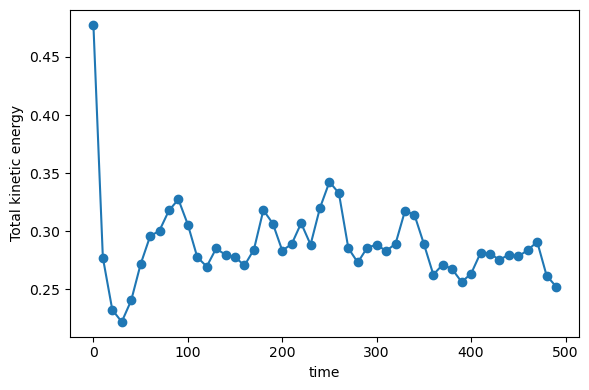

In [10]:
# ----------------------------
# Plot Energy over time
# ----------------------------
import matplotlib.pyplot as plt

T, Nx, Nyh = traj_hat.shape
Ny = 2 * (Nyh - 1)

Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
dx = Lx / Nx
dy = Ly / Ny

kx = 2.0 * jnp.pi * jnp.fft.fftfreq(Nx, d=dx)      # (Nx,)
ky = 2.0 * jnp.pi * jnp.fft.rfftfreq(Ny, d=dy)     # (Ny//2+1,)

KX = kx[:, None]                                    # (Nx,1)
KY = ky[None, :]                                    # (1,Ny//2+1)
K2 = KX**2 + KY**2
K2_safe = jnp.where(K2 == 0, 1.0, K2)

if "t_saved" not in globals() or (hasattr(t_saved, "shape") and t_saved.shape[0] != T):
    save_every = 1.0
    try:
        save_every = float(dt * inner_steps)
    except Exception:
        pass
    t_saved = save_every * jnp.arange(T)

def energy_from_omega_hat(omega_hat_t):
    psi_hat = -omega_hat_t / K2_safe
    psi_hat = psi_hat.at[0, 0].set(0.0 + 0.0j)

    u_hat = (1j * KY) * psi_hat
    v_hat = (-1j * KX) * psi_hat

    u = jnp.fft.irfftn(u_hat, s=(Nx, Ny))
    v = jnp.fft.irfftn(v_hat, s=(Nx, Ny))

    return 0.5 * jnp.sum(u**2 + v**2) * dx * dy

E_t = jax.vmap(energy_from_omega_hat)(traj_hat)

plt.figure(figsize=(6,4))
plt.plot(np.asarray(t_saved), np.asarray(E_t), marker="o")
plt.xlabel("time")
plt.ylabel("Total kinetic energy")
plt.tight_layout()
plt.show()

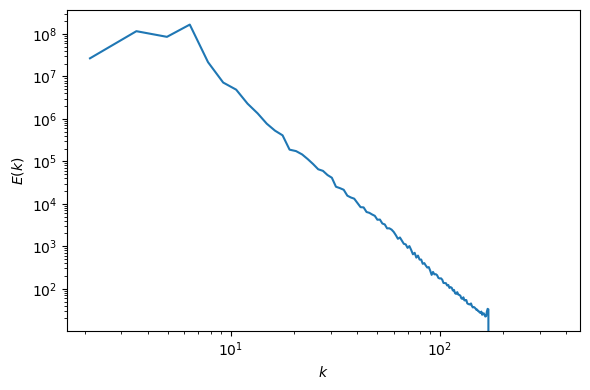

In [11]:
# ----------------------------
# Plot Energy Spectrum
# ----------------------------
T, Nx, Nyh = traj_hat.shape
Ny = 2 * (Nyh - 1)

omega_hat_last = traj_hat[-1]  # (Nx, Ny//2+1)

# domain/grid
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
dx = Lx / Nx
dy = Ly / Ny

kx = 2.0 * jnp.pi * jnp.fft.fftfreq(Nx, d=dx)      # (Nx,)
ky = 2.0 * jnp.pi * jnp.fft.rfftfreq(Ny, d=dy)     # (Ny//2+1,)

KX = kx[:, None]
KY = ky[None, :]
K2 = KX**2 + KY**2
K = jnp.sqrt(K2)

K2_safe = jnp.where(K2 == 0, 1.0, K2)

psi_hat = -omega_hat_last / K2_safe
psi_hat = psi_hat.at[0, 0].set(0.0 + 0.0j)

u_hat = (1j * KY) * psi_hat
v_hat = (-1j * KX) * psi_hat

Ehat = 0.5 * (jnp.abs(u_hat)**2 + jnp.abs(v_hat)**2)

w = jnp.ones((Nyh,), dtype=Ehat.dtype)
if Ny % 2 == 0 and Nyh >= 2:
    w = w.at[1:Nyh-1].set(2.0)   # interior doubled; endpoints unique
else:
    w = w.at[1:].set(2.0)        # only ky=0 unique

Ehat_w = Ehat * w[None, :]

K_np = np.asarray(K, dtype=np.float64)
E_np = np.asarray(Ehat_w, dtype=np.float64)

kmax = float(K_np.max())
nbins = int(min(Nx, Ny) // 2)
bins = np.linspace(0.0, kmax, nbins + 1)

k_flat = K_np.ravel()
E_flat = E_np.ravel()

Ek, _ = np.histogram(k_flat, bins=bins, weights=E_flat)
k_centers = 0.5 * (bins[:-1] + bins[1:])

# plot
plt.figure(figsize=(6,4))
plt.loglog(k_centers[1:], Ek[1:])
plt.xlabel(r"$k$")
plt.ylabel(r"$E(k)$")
plt.tight_layout()
plt.show()

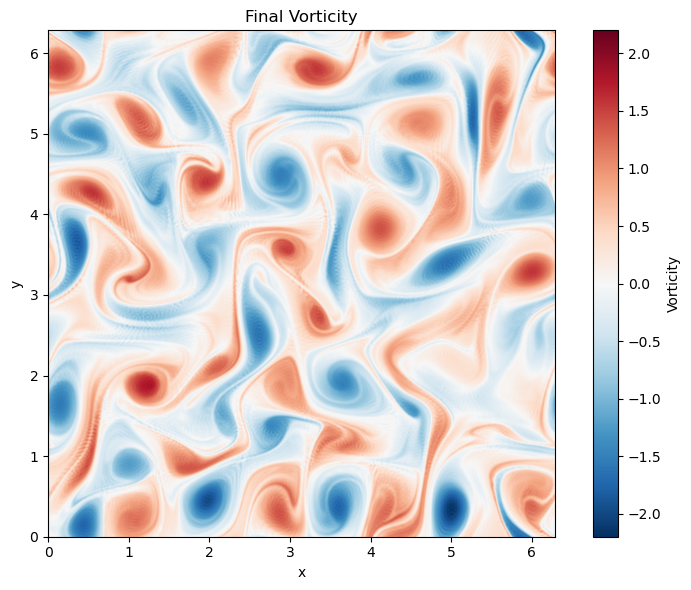

In [12]:
# ----------------------------
# Plot the final snapshot 
# ----------------------------
omega_last = jnp.fft.irfftn(omega_hat_last, s=(Nx, Ny))

omega_last_np = np.asarray(omega_last)

vmax = np.max(np.abs(omega_last_np))

plt.figure(figsize=(8, 6))

plt.imshow(
    omega_last_np,
    cmap="RdBu_r",
    origin="lower",
    extent=[0, 2*np.pi, 0, 2*np.pi],
    vmin=-vmax,
    vmax=vmax,
)

plt.colorbar(label="Vorticity")
plt.title("Final Vorticity")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------
# Save the final snapshot
# ----------------------------
omega_last = jnp.fft.irfftn(omega_hat_last, s=(Nx, Ny))
omega_last_np = np.asarray(omega_last, dtype=np.float32)

x = np.linspace(0, 2*np.pi, Nx, endpoint=False)
y = np.linspace(0, 2*np.pi, Ny, endpoint=False)

ds = xr.Dataset(
    {
        "w": (("y", "x"), omega_last_np)
    },
    coords={
        "x": x,
        "y": y,
    },
    attrs={   # GLOBAL attrs are cleaner than DataArray attrs
        "description": "2D vorticity field (spin-up IC)",
        "nu": float(nu),
        "drag": float(drag),
        "kf": float(kf),
        "amp": float(amp),
        "forcing": "checkerboard",
        "dt": float(dt),
        "save_every": float(SAVE_EVERY),
        "outer_steps": int(outer_steps),
        "inner_steps": int(inner_steps),
        "seed": int(seed),
        "domain": "[0, 2π) periodic",
        "resolution": int(Nx),
    },
)

print(ds)

OUT = Path(OUT)          # ensures Path object
OUT.parent.mkdir(parents=True, exist_ok=True)

ds.to_netcdf(
    OUT,
    format="NETCDF4",
    engine="netcdf4"
)

print("Saved ", OUT)